# Example 14: Knot supervised

In [1]:
import pandas as pd
import numpy as np
import torch
from kan import *
import copy

#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# return error if cuda at plotting - could happen due to cpu cacluation
device = torch.device('cpu')
print(device)

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Download data: https://colab.research.google.com/github/deepmind/mathematics_conjectures/blob/main/knot_theory.ipynb#scrollTo=l10N2ZbHu6Ob

#pip install pandas gcsfs
df = pd.read_csv("https://storage.googleapis.com/maths_conjectures/knot_theory/knot_theory_invariants.csv")
df.keys()

X = df[df.keys()[1:-1]].to_numpy()
Y = df[['signature']].to_numpy()

# normalize X
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X = (X - X_mean[np.newaxis,:])/X_std[np.newaxis,:]
input_normalier = [X_mean, X_std]

# normalize Y
max_signature = np.max(Y)
min_signature = np.min(Y)
Y = ((Y-min_signature)/2).astype(int)
n_class = int((max_signature-min_signature)/2+1) # = 14
output_normalier = [min_signature, 2]

dataset = {}
num = X.shape[0]
n_feature = X.shape[1]
train_ratio = 0.8
train_id_ = np.random.choice(num, int(num*train_ratio), replace=False)
test_id_ = np.array(list(set(range(num))-set(train_id_)))

dtype = torch.get_default_dtype()
dataset['train_input'] = torch.from_numpy(X[train_id_]).type(dtype).to(device)
dataset['train_label'] = torch.from_numpy(Y[train_id_][:,0]).type(torch.long).to(device)
dataset['test_input'] = torch.from_numpy(X[test_id_]).type(dtype).to(device)
dataset['test_label'] = torch.from_numpy(Y[test_id_][:,0]).type(torch.long).to(device)


cpu


In [2]:
def train_acc():
    return torch.mean((torch.argmax(model(dataset['train_input']), dim=1) == dataset['train_label']).float())

def test_acc():
    return torch.mean((torch.argmax(model(dataset['test_input']), dim=1) == dataset['test_label']).float())

model = KAN(width=[n_feature,1,n_class], grid=5, k=3, seed=seed, device=device) #17,1,14
model.fit(dataset, lamb=0.005, batch=1024, loss_fn = nn.CrossEntropyLoss(), metrics=[train_acc, test_acc], display_metrics=['train_loss', 'reg', 'train_acc', 'test_acc']);

checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                          | 0/100 [00:00<?, ?it/s]

 train_loss: 8.24e-01 | reg: 3.25e+01 | train_acc: 7.01e-01 | test_acc: 7.02e-01 |: 100%|█| 100/100 

saving model version 0.1


### seed = 42

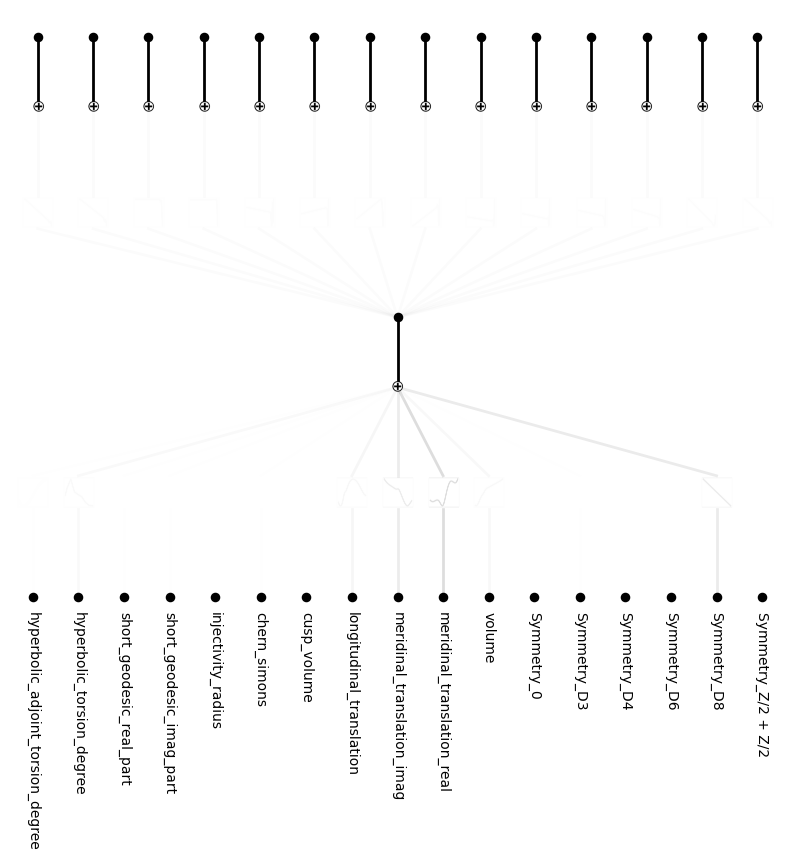

In [3]:
# seed = 42
model.plot(scale=1.0, beta=0.2)

n = 17
for i in range(n):
    plt.gcf().get_axes()[0].text(1/(2*n)+i/n-0.005,-0.02,df.keys()[1:-1][i], rotation=270, rotation_mode="anchor")

Text(0.5, 1.0, 'feature importance - seed = 42')

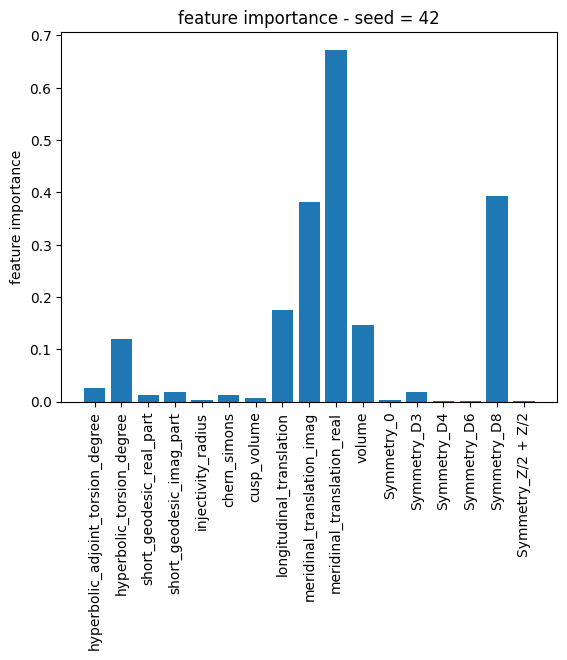

In [4]:
# seed = 42
scores = model.feature_score
if torch.is_tensor(scores):
    scores = scores.detach().cpu().numpy()

features = list(df.keys()[1:-1])

y_pos = range(len(features))
plt.bar(y_pos, scores)
plt.xticks(y_pos, features, rotation=90)
plt.ylabel("feature importance")

plt.title("feature importance - seed = 42")

In [ ]:
model.suggest_symbolic(0,1,0) # fixing (0,1,0) with x, r2=0.34928297996520996, c=1

  function  fitting r2   r2 loss  complexity  complexity loss  total loss
0        0    0.000000  0.000014           0                0    0.000003
1    1/x^2    0.974900 -5.315591           2                2    0.536882
2        x    0.349283 -0.619876           1                1    0.676025
3      1/x    0.941550 -4.096414           2                2    0.780717
4      cos    0.839449 -2.638803           2                2    1.072239


('0',
 (<function kan.utils.<lambda>(x)>,
  <function kan.utils.<lambda>(x)>,
  0,
  <function kan.utils.<lambda>(x, y_th)>),
 0.0,
 0)

In [ ]:
model.suggest_symbolic(0,4,0, topk = 10) #fixing (0,4,0) with x, r2=0.17634715139865875, c=1

    function  fitting r2   r2 loss  complexity  complexity loss  total loss
0          0    0.000000  0.000014           0                0    0.000003
1          x    0.176347 -0.279874           1                1    0.744025
2        x^2    0.844113 -2.681337           2                2    1.063733
3        cos    0.843978 -2.680090           2                2    1.063982
4        sin    0.843964 -2.679953           2                2    1.064009
5        exp    0.640112 -1.474341           2                2    1.305132
6      1/x^2    0.566480 -1.205798           2                2    1.358840
7        1/x    0.524960 -1.073848           2                2    1.385230
8  1/sqrt(x)    0.482703 -0.950907           2                2    1.409819
9    1/x^0.5    0.482703 -0.950907           2                2    1.409819


('0',
 (<function kan.utils.<lambda>(x)>,
  <function kan.utils.<lambda>(x)>,
  0,
  <function kan.utils.<lambda>(x, y_th)>),
 0.0,
 0)

In [7]:
model.suggest_symbolic(0,11,0) #fixing (0,11,0) with x, r2=1.0000008344650269, c=1

  function  fitting r2    r2 loss  complexity  complexity loss  total loss
0        x    1.000001 -16.735349           1                1   -2.547070
1      x^2    1.000001 -16.792769           2                2   -1.758554
2      sin    1.000001 -16.792769           2                2   -1.758554
3      log    1.000001 -16.792769           2                2   -1.758554
4    1/x^2    1.000001 -16.792769           2                2   -1.758554


('x',
 (<function kan.utils.<lambda>(x)>,
  <function kan.utils.<lambda>(x)>,
  1,
  <function kan.utils.<lambda>(x, y_th)>),
 1.0000008344650269,
 1)

In [ ]:
model.suggest_symbolic(0,15,0, topk = 10) # fixing (0,15,0) with x, r2=1.0000008344650269, c=1


    function  fitting r2    r2 loss  complexity  complexity loss  total loss
0          x    1.000001 -16.735349           1                1   -2.547070
1        sin    1.000001 -16.832359           2                2   -1.766472
2        x^2    1.000001 -16.812429           2                2   -1.762486
3        cos    1.000001 -16.792769           2                2   -1.758554
4        log    1.000001 -16.792769           2                2   -1.758554
5  1/sqrt(x)    1.000001 -16.792769           2                2   -1.758554
6      x^0.5    1.000001 -16.792769           2                2   -1.758554
7       sqrt    1.000001 -16.792769           2                2   -1.758554
8    1/x^0.5    1.000001 -16.792769           2                2   -1.758554
9      1/x^2    1.000001 -16.792769           2                2   -1.758554


('x',
 (<function kan.utils.<lambda>(x)>,
  <function kan.utils.<lambda>(x)>,
  1,
  <function kan.utils.<lambda>(x, y_th)>),
 1.0000008344650269,
 1)

In [9]:
model.suggest_symbolic(1,0,0) # fixing (1,0,0) with x, r2=0.08115503937005997, c=1

  function  fitting r2   r2 loss  complexity  complexity loss  total loss
0        0    0.000000  0.000014           0                0    0.000003
1        x    0.081155 -0.122091           1                1    0.775582
2      sin    0.439007 -0.833921           2                2    1.433216
3      cos    0.439007 -0.833921           2                2    1.433216
4      x^2    0.239189 -0.394371           2                2    1.521126


('0',
 (<function kan.utils.<lambda>(x)>,
  <function kan.utils.<lambda>(x)>,
  0,
  <function kan.utils.<lambda>(x, y_th)>),
 0.0,
 0)

In [12]:
model.suggest_symbolic(1,0,12, topk = 10) # fixing (1,0,12) with x, r2=0.49475154280662537, c=1
# Why choose sin instead of cos, 0, x??

    function  fitting r2   r2 loss  complexity  complexity loss  total loss
0          0    0.000000  0.000014           0                0    0.000003
1          x    0.494752 -0.984907           1                1    0.603019
2        exp    0.945317 -4.192494           2                2    0.761501
3      1/x^2    0.920930 -3.660547           2                2    0.867891
4        1/x    0.906133 -3.413086           2                2    0.917383
5  1/sqrt(x)    0.889654 -3.179762           2                2    0.964048
6    1/x^0.5    0.889654 -3.179762           2                2    0.964048
7        cos    0.870196 -2.945480           2                2    1.010904
8        sin    0.869614 -2.939030           2                2    1.012194
9        log    0.850500 -2.741688           2                2    1.051662


('0',
 (<function kan.utils.<lambda>(x)>,
  <function kan.utils.<lambda>(x)>,
  0,
  <function kan.utils.<lambda>(x, y_th)>),
 0.0,
 0)

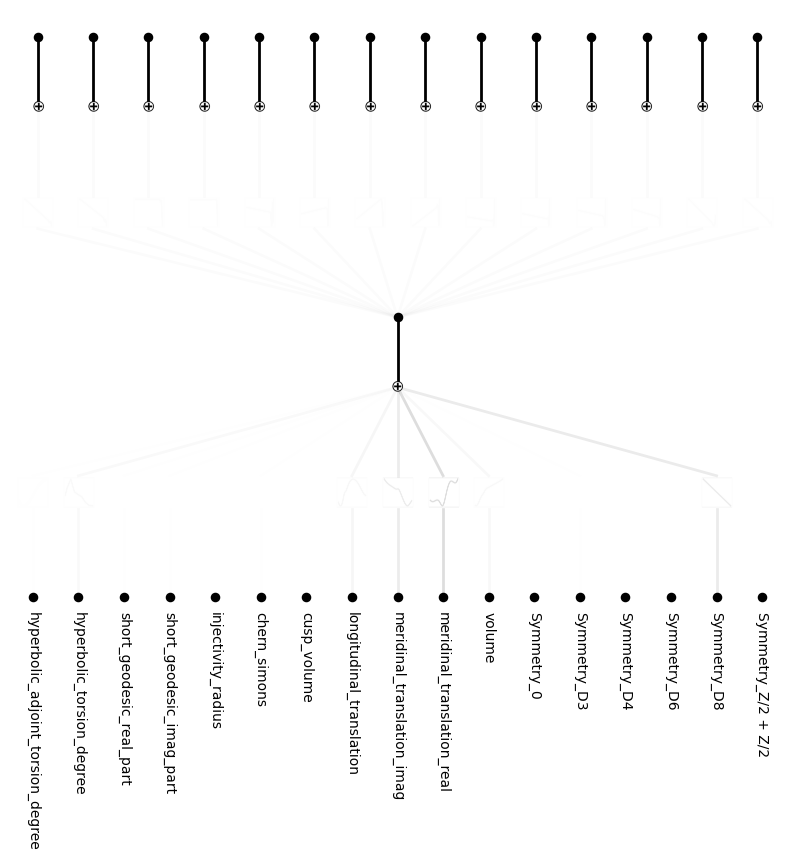

In [13]:
# seed = 42
model.plot(scale=1.0, beta=0.2)

n = 17
for i in range(n):
    plt.gcf().get_axes()[0].text(1/(2*n)+i/n-0.005,-0.02,df.keys()[1:-1][i], rotation=270, rotation_mode="anchor")

In [14]:
# Use a safer library (drop 'tan' which can blow up / destabilize symbolic fitting)
lib = ['x', 'x^2', 'x^3', 'x^4', 'exp', 'log', 'sqrt', 'tanh', 'sin', 'abs']

model.auto_symbolic(lib=lib)
formula = model.symbolic_formula()[0][0]
ex_round(formula, 4)


fixing (0,0,0) with sin, r2=0.9943732023239136, c=2
fixing (0,1,0) with x, r2=0.34928297996520996, c=1
fixing (0,2,0) with x, r2=0.01583431102335453, c=1
fixing (0,3,0) with sin, r2=0.987151026725769, c=2
fixing (0,4,0) with x, r2=0.17634715139865875, c=1
fixing (0,5,0) with sin, r2=0.983031690120697, c=2
fixing (0,6,0) with x, r2=0.002546959090977907, c=1
fixing (0,7,0) with x, r2=0.8887973427772522, c=1
fixing (0,8,0) with x, r2=0.7870970964431763, c=1
fixing (0,9,0) with x, r2=0.7300978302955627, c=1
fixing (0,10,0) with x, r2=0.9163302183151245, c=1
fixing (0,11,0) with x, r2=1.0000008344650269, c=1
fixing (0,12,0) with x, r2=1.0000009536743164, c=1
fixing (0,13,0) with x, r2=1.0000009536743164, c=1
fixing (0,14,0) with x, r2=1.0000016689300537, c=1
fixing (0,15,0) with x, r2=1.0000008344650269, c=1
fixing (0,16,0) with x, r2=1.0000008344650269, c=1
fixing (1,0,0) with x, r2=0.08115503937005997, c=1
fixing (1,0,1) with x, r2=0.263478547334671, c=1
fixing (1,0,2) with x, r2=0.664620

-0.0214*x_10 - 0.0052*x_11 + 0.0001*x_12 + 0.0007*x_13 + 0.0118*x_16 + 0.0026*x_2 - 0.e-4*x_3 - 0.0061*x_8 + 0.0126*x_9 - 0.0042*sin(0.8557*x_1 + 4.3785) + 0.001*sin(1.9842*x_4 + 2.3769) - 0.0009*sin(1.1804*x_6 - 1.1854) - 6.8472

### Seed = 222

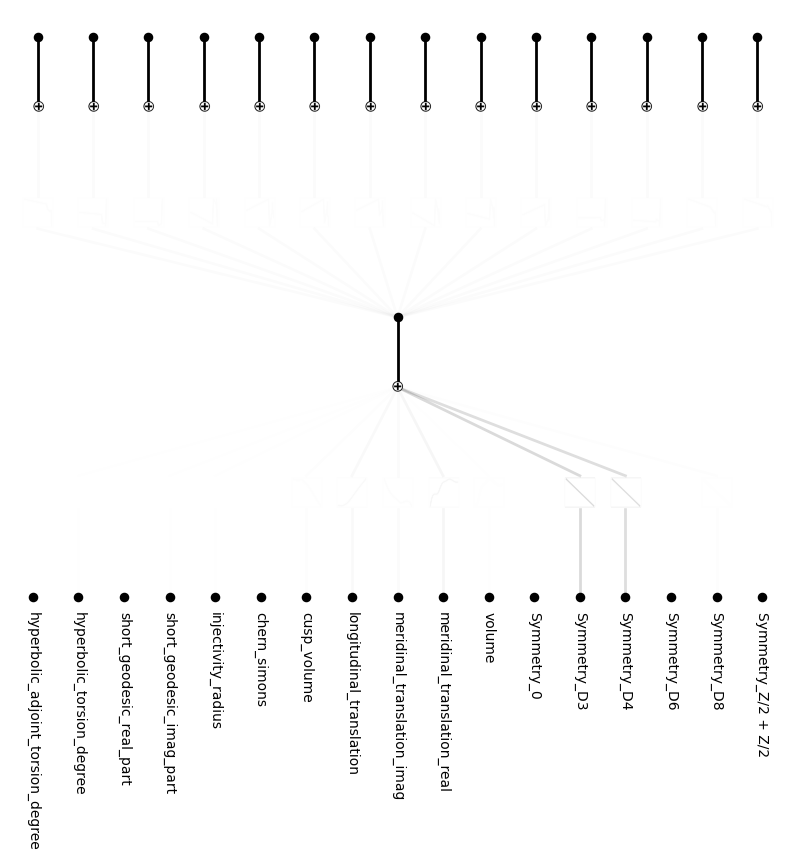

In [ ]:
# seed = 222
model.plot(scale=1.0, beta=0.2)

n = 17
for i in range(n):
    plt.gcf().get_axes()[0].text(1/(2*n)+i/n-0.005,-0.02,df.keys()[1:-1][i], rotation=270, rotation_mode="anchor")

Text(0.5, 1.0, 'feature importance - seed = 222')

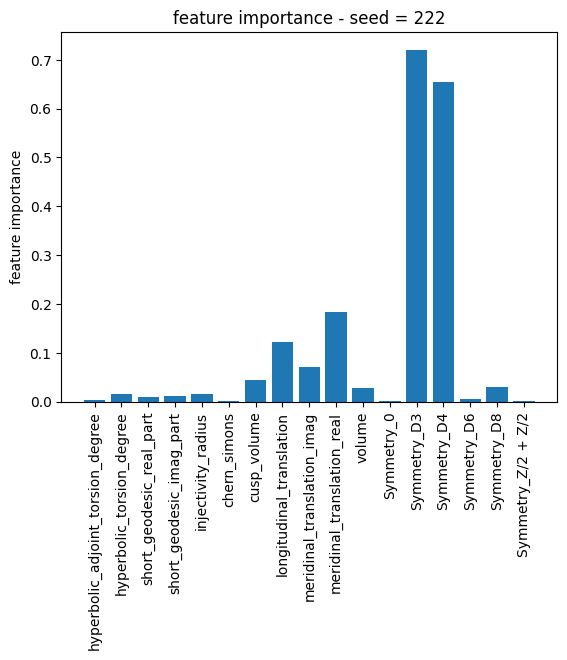

In [14]:
scores = model.feature_score
if torch.is_tensor(scores):
    scores = scores.detach().cpu().numpy()

features = list(df.keys()[1:-1])

y_pos = range(len(features))
plt.bar(y_pos, scores)
plt.xticks(y_pos, features, rotation=90)
plt.ylabel("feature importance")
plt.title("feature importance - seed = 222")